# INN - Week 2

## Quick Tour of TensorFlow



TensorFlow is a powerful library for numerical computation, particularly
well suited and fine-tuned for large-scale Machine Learning (but you could use
it for anything else that requires heavy computations). It was developed by the Google Brain team and it powers many of Google's large-scale services, such as Google Cloud Speech, Google Photos, and Google Search.
- It was open sourced in November 2015, and it is now the most popular deep learning library (in terms of citations in papers, adoption in companies, stars on github, etc.):
- countless projects use TensorFlow for all sorts of Machine Learning tasks, such as image classification, natural language processing (NLP), recommender systems, time series forecasting, and much more.

### So what does TensorFlow actually offer? Here’s a summary:
* Its core is very similar to NumPy, but with GPU support.
* It also supports distributed computing (across multiple devices and servers).
* It includes a kind of just-in-time (JIT) compiler that allows it to optimize computations for speed and memory usage: it works by extracting the computation
graph from a Python function, then optimizing it (e.g., by pruning unused nodes)
and finally running it efficiently (e.g., by automatically running independent
operations in parallel).
* Computation graphs can be exported to a portable format, so you can train a
TensorFlow model in one environment (e.g., using Python on Linux), and run it
in another (e.g., using Java on an Android device).
* It implements autodiff (gradient computation), and provides some excellent optimizers, such as RMSProp, Nadam and FTRL, so you can easily minimize all sorts of loss functions.
* TensorFlow offers many more features, built on top of these core features: the
most important is of course tf.keras, but it also has data loading & preprocessing ops (tf.data, tf.io, etc.), image processing ops (tf.image), signal processing ops (tf.signal), and more...

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Print TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [2]:
# Check if GPU is available
if tf.test.gpu_device_name():
    print('GPU is available')
else:
    print('GPU is not available')

# HOW TO USE GPU SUPPORT IN COLAB?
# !!!CHANGE RUNTIME TO GET GPU SUPPORT

GPU is available


In [3]:
!nvidia-smi


Thu Feb  5 17:36:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P0             27W /   70W |     102MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Example 1: Basic Tensor Data Types
# Create tensors with different data types
tensor_int = tf.constant(4, dtype=tf.int32)
tensor_float = tf.constant(4.0, dtype=tf.float32)
tensor_string = tf.constant("Hello, TensorFlow!", dtype=tf.string)

print(f"Integer Tensor: {tensor_int}, Data Type: {tensor_int.dtype}")
print(f"Float Tensor: {tensor_float}, Data Type: {tensor_float.dtype}")
print(f"String Tensor: {tensor_string}, Data Type: {tensor_string.dtype}")


Integer Tensor: 4, Data Type: <dtype: 'int32'>
Float Tensor: 4.0, Data Type: <dtype: 'float32'>
String Tensor: b'Hello, TensorFlow!', Data Type: <dtype: 'string'>


In [6]:
# Example 2: Data Types in Keras Layers
# Define a simple model with specific data types
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,), dtype=tf.float32),
    keras.layers.Dense(10, activation='softmax', dtype=tf.float32)
])



In [7]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display the model's architecture
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

# Example 3: Converting Data Types
# Create a tensor and convert its data type
tensor_original = tf.constant([1.2, 2.3, 3.4], dtype=tf.float32)
tensor_converted = tf.cast(tensor_original, dtype=tf.float64)

print(f"Original Tensor: {tensor_original}, Data Type: {tensor_original.dtype}")
print(f"Converted Tensor: {tensor_converted}, Data Type: {tensor_converted.dtype}")


Original Tensor: [1.2 2.3 3.4], Data Type: <dtype: 'float32'>
Converted Tensor: [1.20000005 2.29999995 3.4000001 ], Data Type: <dtype: 'float64'>


In [9]:
# tensor to array
tensor_2_array = tf.constant([1.2, 2.3, 3.4], dtype=tf.float32).numpy()
tensor_2_array

array([1.2, 2.3, 3.4], dtype=float32)

In [10]:
# Create a NumPy array
numpy_array = np.array([1, 2, 3, 4, 5])

# Convert the NumPy array to a TensorFlow tensor
tensor_vector = tf.convert_to_tensor(numpy_array)

# Print the tensor vector
print(tensor_vector)

tf.Tensor([1 2 3 4 5], shape=(5,), dtype=int64)


In [11]:

# Example 4: Using tf.data.Dataset with Specific Data Types
# Generate synthetic data
data = np.random.random((1000, 20)).astype(np.float32)
labels = np.random.randint(2, size=(1000, 1)).astype(np.int32)

# Create a tf.data.Dataset
dataset = tf.data.Dataset.from_tensor_slices((data, labels))
print(dataset)
# Print the data types of the dataset elements
for element in dataset.take(1):
    print(f"Data: {element[0]}, Data Type: {element[0].dtype}")
    print(f"Label: {element[1]}, Data Type: {element[1].dtype}")


<_TensorSliceDataset element_spec=(TensorSpec(shape=(20,), dtype=tf.float32, name=None), TensorSpec(shape=(1,), dtype=tf.int32, name=None))>
Data: [0.7905934  0.746976   0.49921373 0.12635958 0.16985658 0.12987451
 0.1810725  0.84167546 0.15029803 0.6143296  0.01656731 0.84717196
 0.33500108 0.24068226 0.15696596 0.2211737  0.19108267 0.54959935
 0.8756415  0.6359617 ], Data Type: <dtype: 'float32'>
Label: [1], Data Type: <dtype: 'int32'>


In [12]:
# Example 5: Specifying Data Types in tf.data.Dataset
# Create a dataset with specified data types
dataset = tf.data.Dataset.from_tensor_slices((data, labels)).map(lambda x, y: (tf.cast(x, tf.float64), tf.cast(y, tf.int64)))

# Print the data types of the dataset elements
for element in dataset.take(1):
    print(f"Data: {element[0]}, Data Type: {element[0].dtype}")
    print(f"Label: {element[1]}, Data Type: {element[1].dtype}")


Data: [0.79059339 0.74697602 0.49921373 0.12635958 0.16985658 0.12987451
 0.1810725  0.84167546 0.15029803 0.61432958 0.01656731 0.84717196
 0.33500108 0.24068226 0.15696596 0.2211737  0.19108267 0.54959935
 0.87564152 0.63596171], Data Type: <dtype: 'float64'>
Label: [1], Data Type: <dtype: 'int64'>


In [13]:
dataset

<_MapDataset element_spec=(TensorSpec(shape=(20,), dtype=tf.float64, name=None), TensorSpec(shape=(1,), dtype=tf.int64, name=None))>

In [ ]:
#create tensor vector



So far, we have used constant tensors: as their name suggests, you cannot modify
them. However, the weights in a neural network need to be tweaked by backpropagation,
and other parameters may also need to change over time (e.g., a momentum
optimizer keeps track of past gradients). What we need is a tf.Variable:

In [ ]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
v

<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>

### Other Data Structures

- Sparse tensors (tf.SparseTensor) efficiently represent tensors containing mostly
0s. The tf.sparse package contains operations for sparse tensors.
- Tensor arrays (tf.TensorArray) are lists of tensors. They have a fixed size by
default, but can optionally be made dynamic. All tensors they contain must have
the same shape and data type.
- Ragged tensors (tf.RaggedTensor) represent static lists of lists of tensors, where
every tensor has the same shape and data type. The tf.ragged package contains
operations for ragged tensors.
- String tensors are regular tensors of type tf.string. These actually represent byte
strings, not Unicode strings, so if you create a string tensor using a Unicode
string (e.g., a regular Python 3 string like "café"`), then it will get encoded to
UTF-8 automatically (e.g., b"caf\xc3\xa9"). Alternatively, you can represent
Unicode strings using tensors of type tf.int32, where each item represents a
Unicode codepoint (e.g., [99, 97, 102, 233]). The tf.strings package (with
an s) contains ops for byte strings and Unicode strings (and to convert one into
the other).
- Sets are just represented as regular tensors (or sparse tensors) containing one or
more sets, and you can manipulate them using operations from the tf.sets
package.
- Queues, including First In, First Out (FIFO) queues (FIFOQueue), queues that can
prioritize some items (PriorityQueue), queues that shuffle their items (Random
ShuffleQueue), and queues that can batch items of different shapes by padding
(PaddingFIFOQueue). These classes are all in the tf.queue package.

## Training FNN on MNIST dataset - use case example

Another classic problem is to classify hand written digits. The corresponding dataset and problem is called MNIST. The figure shows an example of a handwritten digit classified as ``5''.
  
The MNIST task is an instance of a **multiclass classification problem**.

### Dataset for Training

Let us set up the data for the MNIST problem. Standard datasets such as the MNIST dataset are in included in the Tensorflow package. Also the dataset has already been split into a training and a test set.

Load packages

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [15]:
# Load MNIST dataset and preprocess
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


We can print out an example and plot it.

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

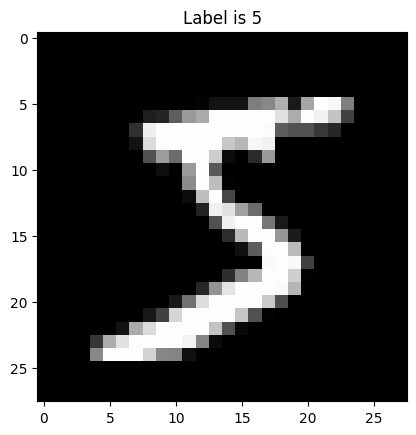

In [ ]:
# Show first example of x_train: images coded in grayscale
print(x_train[0,:,:])

# Plot an example
label=y_train[0]
plt.title('Label is {label}'.format(label=label))
plt.imshow(x_train[0,:,:], cmap='gray')
plt.show()

NN and DL models do not like large numbers, so we normalize the input data to a range [0,1].

In [ ]:
# Convert values to [0,1]
x_train, x_test = x_train / 255.0, x_test / 255.0

We thus get a dataset for training and testing with sizes

In [ ]:
# Size of datasets
print("Size of training dataset:", len(x_train))
print("Size of test dataset:", len(x_test))

Size of training dataset: 60000
Size of test dataset: 10000


Training Dataset for MNIST Problem

The input data shape is 28x28 gray pixels values whereas the label data is a label from the set $\{0,1,2,...,9\}$.

In [ ]:
# Shape of training dataset
print("Shape of input training dataset:", x_train.shape)
print("Shape of label training dataset:", y_train.shape)

Shape of input training dataset: (60000, 28, 28)
Shape of label training dataset: (60000,)


### Model

Set up the model's architecture: specifying the number of layers, the number of units in the layers and specifying the output layer.

For each unit we need to set an activation function.

For the hidden layers we usually use the so-called ReLU (rectified linear unit) activation, i.e., $y=\sigma (z) = \begin{cases}
	0 & \text{for } z < 0\\
	z & \text{for } z \ge 0\end{cases}$
which has shown better and faster training results than other activation functions.

For the output layer we need to specify the number of output nodes and the activation function.
The number of output nodes depends on the problem: For a binary classification problem we have one output unit, for multi-classification problems the number of output units corresponds to the number of classes.

The output node's activation function must also correspond to the task at hand.
- the linear activation function $y=\sigma(z) = z$ is used for regression problems,
-he sigmoid activation function $y=\sigma (z) = \frac{1}{1 + e^{- z}}$ outputs a value between $0$ and $1$ and can thus indicate in the output layer a probability score for binary classification tasks. It can also be used for multilabel classification where values do not sum to $1$.
-or multiclass classification the so-called softmax function, i.e., $y=\sigma(\mathbf{z})_j = \frac{e^{z_j}}{\sum_{k=1}^K e^{z_k}}$, is usually used in the output layer as it outputs values between $0$ and $1$ which sum to $1$. Hence its output can be interpreted as a probability distribution.

Let us then set up a simple FNN model for the MNIST problem.

In [ ]:
 # Build model/architecture
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(28, 28)), #input layer
  tf.keras.layers.Flatten(), # flatten layer
  tf.keras.layers.Dense(128, activation='relu'), #hidden layer
  tf.keras.layers.Dense(10) #output layer: 10 nodes for 10 classes. Default activation: linear
])

We can look at the models specifications

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Let us compute the output of the model, without training, and turn it to an array of probabilities.

In [ ]:
predictions = model(x_train[:1]).numpy() #run model for first example, without training, and turn output into numpy array
predictions


array([[-0.13691804, -0.18607053,  0.10469106,  0.29721963,  0.1320244 ,
        -0.08394496, -0.09590357,  0.12180868, -0.94513386, -0.40076593]],
      dtype=float32)

In [ ]:

tf.nn.softmax(predictions).numpy() # this turns the output into probabilities

array([[0.0936081 , 0.08911828, 0.11919086, 0.14449641, 0.12249369,
        0.09870051, 0.09752723, 0.1212487 , 0.04171669, 0.07189949]],
      dtype=float32)

We see that we get a random output, with values roughly around $1/10$.

### Training

Let us then train our FNN model for the MNIST problem.

In [ ]:
 # Loss function: to use for multiclass problem
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# With this loss function the labels should be provided as integers.
# If you want to provide labels using one-hot representation, use CategoricalCrossentropy loss.
# logits: Tensorflow name for what is passed to a softmax function

#### LOGITS=TURE
Why This Matters:
Numerical Stability: Using logits directly (from_logits=True) can provide better numerical stability. TensorFlow's loss functions are optimized to handle logits and apply activation functions in a numerically stable way.
Efficiency: If your model outputs logits, letting the loss function handle the activation avoids redundant computations (e.g., you don't need to apply softmax manually).

#### Example Comparison:


##### Case 1: Without Softmax in the Model (Logits Output)

In [ ]:
# model_example = tf.keras.Sequential([
#     tf.keras.layers.Dense(10)  # No activation here, logits as output
# ])

# loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)


Here, the model outputs logits, and the from_logits=True parameter tells the loss function to handle the softmax transformation internally.

##### Case 2: With Softmax in the Model (Probabilities Output)


In [ ]:
# model_example = tf.keras.Sequential([
#     tf.keras.layers.Dense(10, activation='softmax')  # Softmax applied here
# ])

# loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=False)


Here, the model outputs probabilities (values between 0 and 1), so from_logits=False tells the loss function that the activation has already been applied.

...

In [ ]:
# ...
# The loss is equal to the negative log probability of the the true class: It is zero if the model is sure of the correct class.

# The untrained model gives probabilities close to random (1/10 for each class), so the initial loss should be close to -tf.log(1/10) ~= 2.3.
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.3156652)

Then we compile the model: we choose the 'adam' optimizer, the loss function we have just defined and the accuracy as a metric.

In [ ]:
# Compile model: specify optimizer, loss and metric
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'],
              )

We can now train the model for a number of epochs and evaluate the training progress on the train and test dataset.           
    

In [ ]:
# train
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10) #batch size - 32

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8760 - loss: 0.4350 - val_accuracy: 0.9610 - val_loss: 0.1376
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9653 - loss: 0.1189 - val_accuracy: 0.9720 - val_loss: 0.0935
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9771 - loss: 0.0766 - val_accuracy: 0.9727 - val_loss: 0.0886
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9836 - loss: 0.0557 - val_accuracy: 0.9760 - val_loss: 0.0799
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0445 - val_accuracy: 0.9725 - val_loss: 0.0880
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9903 - loss: 0.0326 - val_accuracy: 0.9768 - val_loss: 0.0792
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9923 - loss: 0.0251 - val_accuracy: 0.9799 - val_loss: 0.0711
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9937 - loss: 0.0209 - 

It is helpful to plot the loss and the accuracy over epochs for both the training and the test dataset.

In [16]:
print(type(history))

NameError: name 'history' is not defined

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

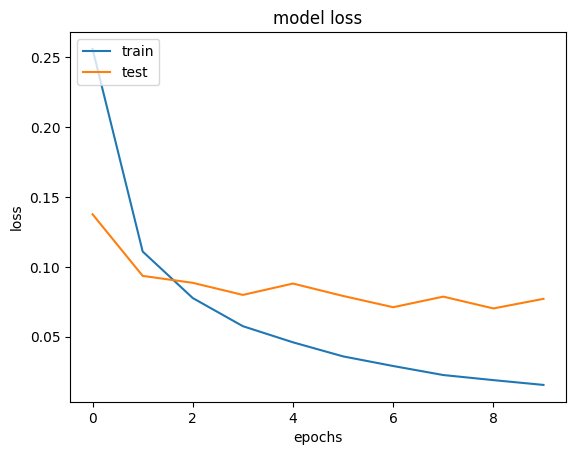

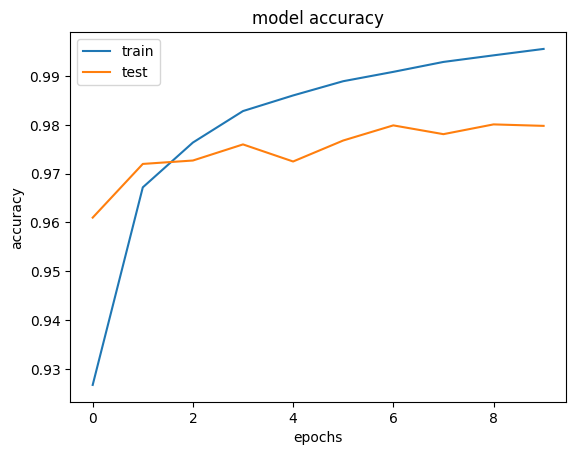

In [ ]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Model Evaluation

Let us see how our model performs on the test dataset.

In [ ]:
model.evaluate(x_test,  y_test, verbose=2) #verbose=2: show time to evaluate

313/313 - 1s - 2ms/step - accuracy: 0.9798 - loss: 0.0771


[0.07710792869329453, 0.9797999858856201]

The model shows a high accuracy on the test dataset. However, it is overfitting.

The model may thus be optimized further by **regularization** techniques.

### Regularization Techniques

Let us here implement here for the moment just one regularization method, adding a dropout layer. We also write the code in a more compact way.

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu'), )
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))
# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # default from_logits=False
# Fit model
model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=2) #batch size default: 32
# Evaluate model
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9055 - loss: 0.3215
Epoch 2/10
1875/1875 - 4s - 2ms/step - accuracy: 0.9518 - loss: 0.1608
Epoch 3/10
1875/1875 - 4s - 2ms/step - accuracy: 0.9620 - loss: 0.1249
Epoch 4/10
1875/1875 - 4s - 2ms/step - accuracy: 0.9671 - loss: 0.1055
Epoch 5/10
1875/1875 - 4s - 2ms/step - accuracy: 0.9708 - loss: 0.0931
Epoch 6/10
1875/1875 - 4s - 2ms/step - accuracy: 0.9741 - loss: 0.0832
Epoch 7/10
1875/1875 - 4s - 2ms/step - accuracy: 0.9754 - loss: 0.0764
Epoch 8/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9780 - loss: 0.0688
Epoch 9/10
1875/1875 - 4s - 2ms/step - accuracy: 0.9791 - loss: 0.0662
Epoch 10/10
1875/1875 - 4s - 2ms/step - accuracy: 0.9798 - loss: 0.0624
Test Accuracy: 0.978


In [ ]:
predictions = model(x_train[:1]).numpy() #run model for first example, without training, and turn output into numpy array
predictions

array([[4.7459778e-14, 5.9793972e-13, 1.1423271e-09, 3.9934879e-03,
        1.2176266e-22, 9.9600655e-01, 3.9883751e-17, 1.0858643e-12,
        1.0007071e-13, 2.7115524e-10]], dtype=float32)

In [ ]:
tf.nn.softmax(predictions).numpy() # this turns the output into probabilities

array([[0.08538653, 0.08538653, 0.08538653, 0.08572821, 0.08538653,
        0.2311796 , 0.08538653, 0.08538653, 0.08538653, 0.08538653]],
      dtype=float32)

#*******************


# Structured Data Classification

This example demonstrates how to do structured data classification, starting from a CSV file. The data includes both numerical and categorical features.

The dataset is provided by the Cleveland Clinic Foundation for Heart Disease. It's a CSV file with 303 rows. Each row contains information about a patient (a sample), and each column describes an attribute of the patient (a feature). The features are used to predict whether a patient has a heart disease, i.e., it is a binary classification problem.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## Preparing data

Let's download the data and load it into a Pandas dataframe.

In [ ]:
file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

The dataset includes 303 samples with 14 columns per sample (13 features, plus the target
label).

In [ ]:
dataframe.shape

(303, 14)

Here's a preview of a few samples:

In [ ]:
dataframe.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


The last column, "target", indicates whether the patient has a heart disease (1) or not
(0).

## Feature preprocessing

The following features are categorical features encoded as integers:

- `sex`
- `cp`
- `fbs`
- `restecg`
- `exang`
- `ca`

We will encode these features using **one-hot encoding**.

We also have a categorical feature encoded as a string: `thal`. We will create an
index of all possible features and one-hot encode the output.

Finally, the following feature are continuous numerical features:

- `age`
- `trestbps`
- `chol`
- `thalach`
- `oldpeak`
- `slope`

For each of these features, we will use normalization to make sure the mean
of each feature is 0 and its standard deviation is 1.

Encode categorical, string and numerical features.

In [ ]:
# Define the categorical and numerical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'ca']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']

# Apply OneHotEncoding on the categorical features
onehotencoder = OneHotEncoder()
onehot_encoded_categorical = onehotencoder.fit_transform(dataframe[categorical_features]).toarray()

# Apply LabelEncoding on the 'thal' feature which is a string
labelencoder = LabelEncoder()
label_encoded = labelencoder.fit_transform(dataframe['thal']).reshape(-1, 1) # Fit label encoder and return encoded labels

# # Number of labels
# num_labels = len(labelencoder.classes_)
# print(f"'thal' feature has {num_labels} unique labels.")

# Now, 'thal' is numeric and can be one-hot encoded
onehotencoder_thal = OneHotEncoder()
onehot_encoded_string = onehotencoder_thal.fit_transform(label_encoded).toarray()

# Apply StandardScaler on the numerical features for better training performance
standard_scaler = StandardScaler()
standard_encoded_numerical = standard_scaler.fit_transform(dataframe[numerical_features])

# Combine the encoded columns with the numerical ones
input_data = np.concatenate([onehot_encoded_categorical, onehot_encoded_string, standard_encoded_numerical], axis=1)
print("Encoded input data:\n", input_data[:5])

# Print the target column
target_data = dataframe['target'].values
print("Target data:\n", target_data[:5])

Encoded input data:
 [[ 0.          1.          0.          1.          0.          0.
   0.          0.          1.          0.          0.          1.
   1.          0.          1.          0.          0.          0.
   0.          0.          1.          0.          0.          0.9338399
   0.74578148 -0.2600867   0.03480774  1.06804543  2.28495852]
 [ 0.          1.          0.          0.          0.          0.
   1.          1.          0.          0.          0.          1.
   0.          1.          0.          0.          0.          1.
   0.          0.          0.          1.          0.          1.3782113
   1.59232914  0.75738769 -1.78061581  0.38022871  0.66354767]
 [ 0.          1.          0.          0.          0.          0.
   1.          1.          0.          0.          0.          1.
   0.          1.          0.          0.          1.          0.
   0.          0.          0.          0.          1.          1.3782113
  -0.66513129 -0.33687722 -0.87290403  1

In [ ]:
input_data.shape

(303, 29)

Splitting into train and validation set

In [ ]:
# Splitting into train and validation set
input_train, input_val, target_train, target_val = train_test_split(input_data, target_data, test_size=0.2, random_state=1337)

## Building model

In [ ]:
model = tf.keras.Sequential([
    layers.Input(shape=(input_train.shape[1],), ), #input layer
    layers.Dense(128, activation='relu'), #, kernel_initializer="he_normal", bias_initializer="zeros",),
    layers.Dropout(0.25),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(1, activation='sigmoid')
  # layers.Dense(1, activation='softmax')

])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
input_train.shape[1]

29

## Training and evaluating

In [ ]:
# Train the model
history = model.fit(input_train, target_train, epochs=10, batch_size=16, validation_data=(input_val, target_val), shuffle=True)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.4495 - loss: 0.7097 - val_accuracy: 0.7869 - val_loss: 0.5369
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6878 - loss: 0.5401 - val_accuracy: 0.8033 - val_loss: 0.4186
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7913 - loss: 0.4161 - val_accuracy: 0.7869 - val_loss: 0.3725
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7889 - loss: 0.3728 - val_accuracy: 0.8361 - val_loss: 0.3650
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8405 - loss: 0.3345 - val_accuracy: 0.8197 - val_loss: 0.3726
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8673 - loss: 0.3145 - val_accuracy: 0.8197 - val_loss: 0.3861
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8613 - loss: 0.2927 - val_accuracy: 0.8197 - val_loss: 0.3969
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8977 - loss: 0.2451 - val_accuracy: 0.8033 - val_los

In [ ]:
# Evaluate the model
val_loss, val_acc = model.evaluate(input_val, target_val)
print(f"Validation accuracy: {val_acc}, Validation loss: {val_loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step - accuracy: 0.8064 - loss: 0.3874
Validation accuracy: 0.8032786846160889, Validation loss: 0.40375223755836487


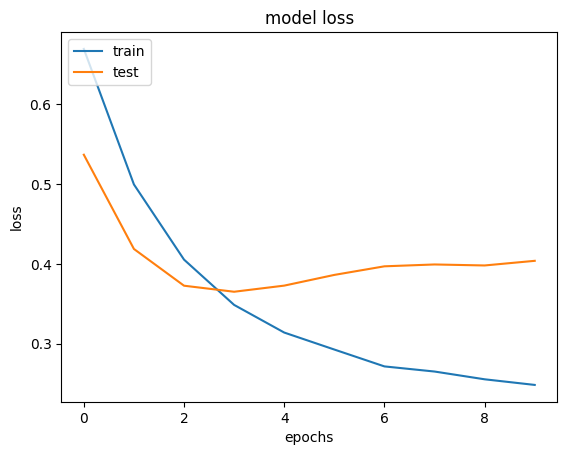

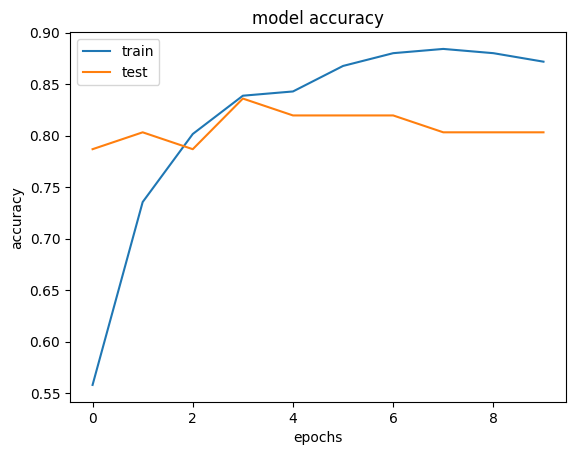

In [ ]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Inference on new data example

> Add blockquote



In [ ]:
# Sample - wrap scalars into a list to have a batch dimension
sample = {
    "age": [60],
    "sex": [1],
    "cp": [1],
    "trestbps": [145],
    "chol": [233],
    "fbs": [1],
    "restecg": [2],
    "thalach": [150],
    "exang": [0],
    "oldpeak": [2.3],
    "slope": [3],
    "ca": [0],
    "thal": ['fixed'],   # Assuming 'fixed' is a category in 'thal'
}

sample_df = pd.DataFrame.from_dict(sample)

Preprocessing the sample in the similar manner as training data, use model for prediction.

In [ ]:
# Preprocessing the sample in the similar manner as training data
# Assuming onehotencoder, labelencoder, onehotencoder_thal, and standard_scaler are defined
onehot_sample = onehotencoder.transform(sample_df[categorical_features]).toarray()

# Apply LabelEncoding on the 'thal' feature which is a string
sample_label_encoded = labelencoder.transform(sample_df['thal']).reshape(-1, 1)
# Now, 'thal' is numeric and can be one-hot encoded
onehot_sample_label_encoded = onehotencoder_thal.transform(sample_label_encoded).toarray()

standard_sample = standard_scaler.transform(sample_df[numerical_features])

# Combine the columns and prepare the input tensor
input_array = np.concatenate([onehot_sample, onehot_sample_label_encoded, standard_sample], axis=1)
input_tensor = tf.convert_to_tensor(input_array, dtype=tf.float32)

# Get the model prediction
probability = model.predict(input_array)[0][0] * 100
print(
    f"This particular patient has a {probability:.1f} "
    "percent probability of having a heart disease, "
    "as evaluated by our model."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
This particular patient has a 23.1 percent probability of having a heart disease, as evaluated by our model.
